#  MODULE 2 : Modélisation Supervisée

## Partie 1 : Préparation des Données — Split 70 / 15 / 15 (stratifié)

> **Ratio fixé** : 70 % Train | 15 % Validation | 15 % Test  
> **Stratification** appliquée sur `Categorie` pour préserver la distribution des classes.

In [21]:
X = df_clean.drop(['Categorie', 'Rapport_Collecte'], axis=1)
y = df_clean['Categorie']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Étape 1 : 70 % Train | 30 % Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y
)

# Étape 2 : Temp → 15 % Val | 15 % Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train : {X_train.shape}  ({len(X_train)/len(X_scaled)*100:.0f} %)")
print(f"Val   : {X_val.shape}    ({len(X_val)/len(X_scaled)*100:.0f} %)")
print(f"Test  : {X_test.shape}   ({len(X_test)/len(X_scaled)*100:.0f} %)")

print("\nDistribution — Train :", pd.Series(y_train).value_counts(normalize=True).round(3).to_dict())
print("Distribution — Val   :", pd.Series(y_val).value_counts(normalize=True).round(3).to_dict())
print("Distribution — Test  :", pd.Series(y_test).value_counts(normalize=True).round(3).to_dict())

Train : (6734, 7)  (70 %)
Val   : (1443, 7)    (15 %)
Test  : (1443, 7)   (15 %)

Distribution — Train : {2: 0.264, 3: 0.245, 0: 0.221, 1: 0.217, 4: 0.053}
Distribution — Val   : {2: 0.265, 3: 0.245, 0: 0.221, 1: 0.217, 4: 0.053}
Distribution — Test  : {2: 0.264, 3: 0.245, 0: 0.22, 1: 0.217, 4: 0.053}


## Partie 2 : Classification — Entraînement des Modèles

### 1. Random Forest

In [22]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_val_rf  = model_rf.predict(X_val)
print(f"[Val] Accuracy: {accuracy_score(y_val, y_val_rf):.3f}")

y_pred_rf = model_rf.predict(X_test)
rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_rec  = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_f1   = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print(f"Random Forest — Accuracy: {rf_acc:.3f} | Precision: {rf_prec:.3f} | Recall: {rf_rec:.3f} | F1: {rf_f1:.3f}")
print("\n", classification_report(y_test, y_pred_rf, zero_division=0))

[Val] Accuracy: 0.955
Random Forest — Accuracy: 0.953 | Precision: 0.944 | Recall: 0.953 | F1: 0.940

               precision    recall  f1-score   support

           0       0.95      0.99      0.97       318
           1       0.95      1.00      0.97       313
           2       0.96      0.99      0.98       381
           3       0.97      1.00      0.98       354
           4       0.71      0.19      0.31        77

    accuracy                           0.95      1443
   macro avg       0.91      0.84      0.84      1443
weighted avg       0.94      0.95      0.94      1443



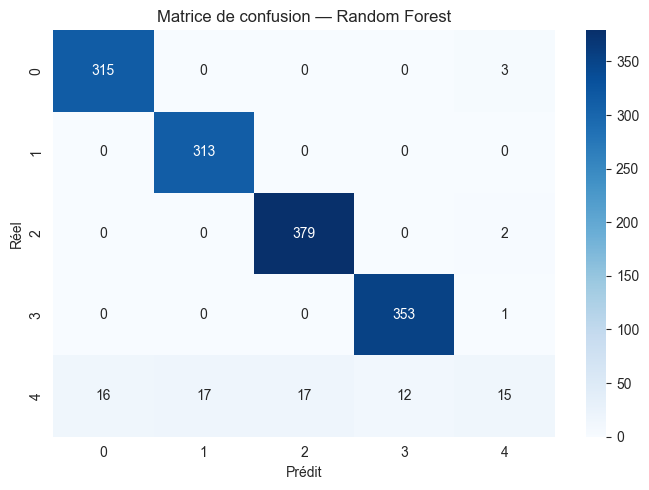

Cross-Validation RF (5 folds) : [0.951 0.952 0.944 0.947 0.949]
Moyenne CV : 0.948 ± 0.003


In [23]:
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédit'); plt.ylabel('Réel')
plt.title('Matrice de confusion — Random Forest')
plt.tight_layout()
plt.show()

cv_scores_rf = cross_val_score(model_rf, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validation RF (5 folds) : {cv_scores_rf.round(3)}")
print(f"Moyenne CV : {cv_scores_rf.mean():.3f} ± {cv_scores_rf.std():.3f}")

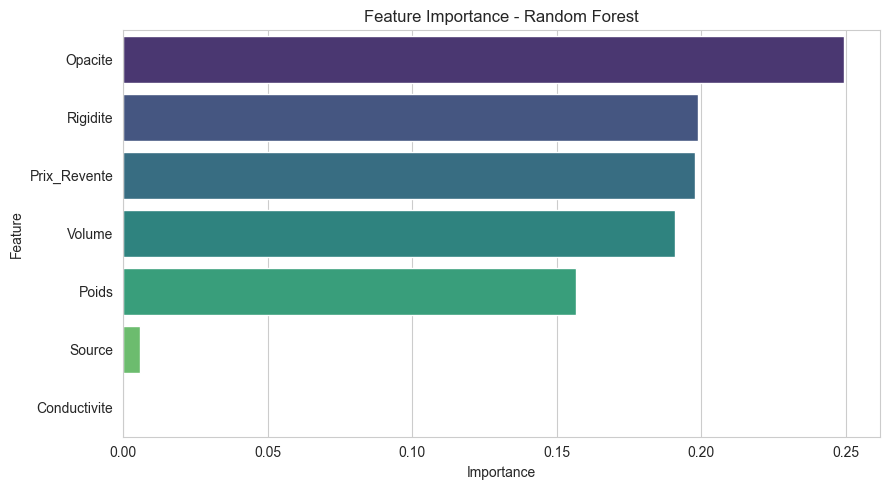

In [24]:
importance_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': model_rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()


### 2. Gradient Boosting Classifier

In [25]:
gbc = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gbc.fit(X_train, y_train)

y_val_gbc = gbc.predict(X_val)
print(f"[Val] Accuracy: {accuracy_score(y_val, y_val_gbc):.3f}")

y_pred_gbc = gbc.predict(X_test)
gbc_acc  = accuracy_score(y_test, y_pred_gbc)
gbc_prec = precision_score(y_test, y_pred_gbc, average='weighted', zero_division=0)
gbc_rec  = recall_score(y_test, y_pred_gbc, average='weighted', zero_division=0)
gbc_f1   = f1_score(y_test, y_pred_gbc, average='weighted', zero_division=0)

print(f"Gradient Boosting — Accuracy: {gbc_acc:.3f} | Precision: {gbc_prec:.3f} | Recall: {gbc_rec:.3f} | F1: {gbc_f1:.3f}")
print("\n", classification_report(y_test, y_pred_gbc, zero_division=0))

[Val] Accuracy: 0.958
Gradient Boosting — Accuracy: 0.956 | Precision: 0.956 | Recall: 0.956 | F1: 0.943

               precision    recall  f1-score   support

           0       0.95      1.00      0.98       318
           1       0.95      1.00      0.97       313
           2       0.96      1.00      0.98       381
           3       0.97      1.00      0.98       354
           4       0.94      0.19      0.32        77

    accuracy                           0.96      1443
   macro avg       0.95      0.84      0.85      1443
weighted avg       0.96      0.96      0.94      1443



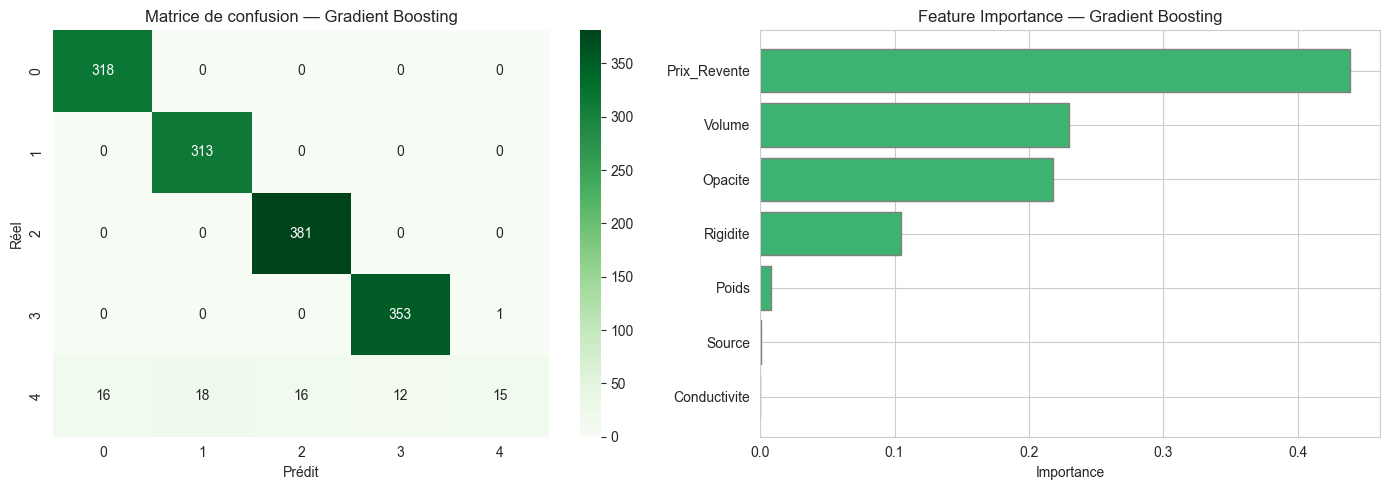

Cross-Validation GBC (5 folds) : [0.955 0.953 0.947 0.954 0.953]
Moyenne CV : 0.952 ± 0.003


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
sns.heatmap(confusion_matrix(y_test, y_pred_gbc), annot=True, fmt='d',
            cmap='Greens', ax=axes[0])
axes[0].set_xlabel('Prédit'); axes[0].set_ylabel('Réel')
axes[0].set_title('Matrice de confusion — Gradient Boosting')

# Feature Importance GBC
importance_gbc = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': gbc.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(importance_gbc['Feature'], importance_gbc['Importance'],
             color='mediumseagreen', edgecolor='grey')
axes[1].set_title('Feature Importance — Gradient Boosting')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

cv_scores_gbc = cross_val_score(gbc, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validation GBC (5 folds) : {cv_scores_gbc.round(3)}")
print(f"Moyenne CV : {cv_scores_gbc.mean():.3f} ± {cv_scores_gbc.std():.3f}")

### 3. k-NN (k optimisé sur la validation)

In [27]:
best_k, best_val_acc = 1, 0
for k in range(1, 21):
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train, y_train)
    acc = accuracy_score(y_val, knn_tmp.predict(X_val))
    if acc > best_val_acc:
        best_val_acc, best_k = acc, k

print(f"Meilleur k (sur Val) = {best_k}  |  Val Accuracy = {best_val_acc:.3f}")

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

knn_acc  = accuracy_score(y_test, y_pred_knn)
knn_prec = precision_score(y_test, y_pred_knn, average='weighted', zero_division=0)
knn_rec  = recall_score(y_test, y_pred_knn, average='weighted', zero_division=0)
knn_f1   = f1_score(y_test, y_pred_knn, average='weighted', zero_division=0)

print(f"kNN (k={best_k}) — Accuracy: {knn_acc:.3f} | Precision: {knn_prec:.3f} | Recall: {knn_rec:.3f} | F1: {knn_f1:.3f}")

Meilleur k (sur Val) = 5  |  Val Accuracy = 0.949
kNN (k=5) — Accuracy: 0.949 | Precision: 0.952 | Recall: 0.949 | F1: 0.927


### 4. Decision Tree (max_depth optimisé)

In [28]:
best_depth, best_val_acc = None, 0
for d in [None, 3, 5, 7, 10, 15]:
    dt_tmp = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt_tmp.fit(X_train, y_train)
    acc = accuracy_score(y_val, dt_tmp.predict(X_val))
    if acc > best_val_acc:
        best_val_acc, best_depth = acc, d

print(f"Meilleur max_depth = {best_depth}  |  Val Accuracy = {best_val_acc:.3f}")

dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

dt_acc  = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt, average='weighted', zero_division=0)
dt_rec  = recall_score(y_test, y_pred_dt, average='weighted', zero_division=0)
dt_f1   = f1_score(y_test, y_pred_dt, average='weighted', zero_division=0)

print(f"Decision Tree (depth={best_depth}) — Accuracy: {dt_acc:.3f} | Precision: {dt_prec:.3f} | Recall: {dt_rec:.3f} | F1: {dt_f1:.3f}")

Meilleur max_depth = 10  |  Val Accuracy = 0.962
Decision Tree (depth=10) — Accuracy: 0.954 | Precision: 0.949 | Recall: 0.954 | F1: 0.940


### 5. SVM Linéaire

In [29]:
svm_l = SVC(kernel='linear', random_state=42)
svm_l.fit(X_train, y_train)
y_pred_svm_l = svm_l.predict(X_test)

svm_l_acc  = accuracy_score(y_test, y_pred_svm_l)
svm_l_prec = precision_score(y_test, y_pred_svm_l, average='weighted', zero_division=0)
svm_l_rec  = recall_score(y_test, y_pred_svm_l, average='weighted', zero_division=0)
svm_l_f1   = f1_score(y_test, y_pred_svm_l, average='weighted', zero_division=0)

print(f"SVM Linéaire — Accuracy: {svm_l_acc:.3f} | Precision: {svm_l_prec:.3f} | Recall: {svm_l_rec:.3f} | F1: {svm_l_f1:.3f}")

SVM Linéaire — Accuracy: 0.942 | Precision: 0.893 | Recall: 0.942 | F1: 0.917


### 6. SVM RBF

In [30]:
svm_k = SVC(kernel='rbf', random_state=42)
svm_k.fit(X_train, y_train)
y_pred_svm_k = svm_k.predict(X_test)

svm_k_acc  = accuracy_score(y_test, y_pred_svm_k)
svm_k_prec = precision_score(y_test, y_pred_svm_k, average='weighted', zero_division=0)
svm_k_rec  = recall_score(y_test, y_pred_svm_k, average='weighted', zero_division=0)
svm_k_f1   = f1_score(y_test, y_pred_svm_k, average='weighted', zero_division=0)

print(f"SVM RBF — Accuracy: {svm_k_acc:.3f} | Precision: {svm_k_prec:.3f} | Recall: {svm_k_rec:.3f} | F1: {svm_k_f1:.3f}")

SVM RBF — Accuracy: 0.946 | Precision: 0.949 | Recall: 0.946 | F1: 0.924


### 7. Régression Logistique

In [31]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

lr_acc  = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
lr_rec  = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
lr_f1   = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)

print(f"Logistic Regression — Accuracy: {lr_acc:.3f} | Precision: {lr_prec:.3f} | Recall: {lr_rec:.3f} | F1: {lr_f1:.3f}")

Logistic Regression — Accuracy: 0.943 | Precision: 0.921 | Recall: 0.943 | F1: 0.920


## Partie 3 : Tableau Comparatif — Classification

In [58]:
results_clf = pd.DataFrame([
    {'Algorithme': 'Random Forest',         'Accuracy': rf_acc,    'Precision': rf_prec,    'Recall': rf_rec,    'F1-score': rf_f1},
    {'Algorithme': 'Gradient Boosting',     'Accuracy': gbc_acc,   'Precision': gbc_prec,   'Recall': gbc_rec,   'F1-score': gbc_f1},
    {'Algorithme': 'kNN',                   'Accuracy': knn_acc,   'Precision': knn_prec,   'Recall': knn_rec,   'F1-score': knn_f1},
    {'Algorithme': 'Decision Tree',         'Accuracy': dt_acc,    'Precision': dt_prec,    'Recall': dt_rec,    'F1-score': dt_f1},
    {'Algorithme': 'SVM Linéaire',          'Accuracy': svm_l_acc, 'Precision': svm_l_prec, 'Recall': svm_l_rec, 'F1-score': svm_l_f1},
    {'Algorithme': 'SVM RBF',               'Accuracy': svm_k_acc, 'Precision': svm_k_prec, 'Recall': svm_k_rec, 'F1-score': svm_k_f1},
    {'Algorithme': 'Logistic Regression',   'Accuracy': lr_acc,    'Precision': lr_prec,    'Recall': lr_rec,    'F1-score': lr_f1},
]).set_index('Algorithme').round(3).sort_values('F1-score', ascending=False)

print("Classement des modèles de Classification :")
display(results_clf.style.background_gradient(cmap='YlGn'))

Classement des modèles de Classification :


,Accuracy,Precision,Recall,F1-score
Algorithme,,,,
Gradient Boosting,0.956000,0.956000,0.956000,0.943000
Random Forest,0.953000,0.944000,0.953000,0.940000
Decision Tree,0.954000,0.949000,0.954000,0.940000
kNN,0.949000,0.952000,0.949000,0.927000
SVM RBF,0.946000,0.949000,0.946000,0.924000
Logistic Regression,0.943000,0.921000,0.943000,0.920000
SVM Linéaire,0.942000,0.893000,0.942000,0.917000


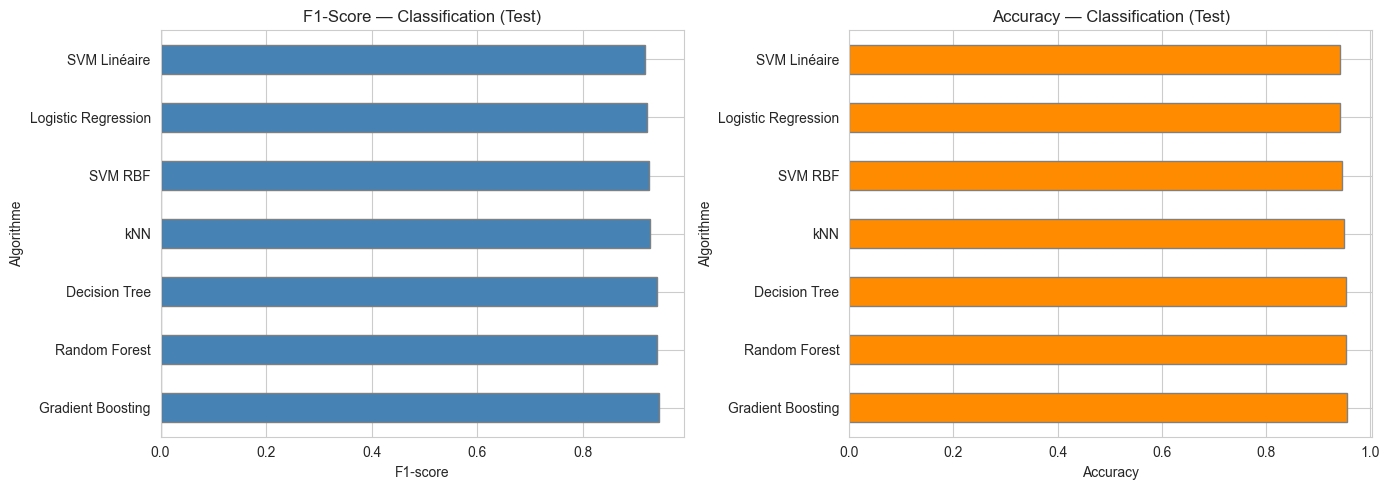

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_clf['F1-score'].plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='grey')
axes[0].set_title('F1-Score — Classification (Test)', fontsize=12)
axes[0].set_xlabel('F1-score')
axes[0].axvline(0, color='black', linewidth=0.8)

results_clf['Accuracy'].plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='grey')
axes[1].set_title('Accuracy — Classification (Test)', fontsize=12)
axes[1].set_xlabel('Accuracy')

plt.tight_layout()
plt.show()